In [39]:
# ============================================================
# FAKE JOB POSTING DETECTION USING NLP AND MACHINE LEARNING
# ============================================================


# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

!pip install nltk scikit-learn pandas matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [40]:
# ============================================================
# 2. DOWNLOAD NLTK RESOURCES
# ============================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [41]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv("fake_job_postings.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED SUCCESSFULLY
Dataset shape: (17880, 18)

First 5 rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [42]:
# ============================================================
# 4. BASIC DATASET INFORMATION
# ============================================================

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()


Column names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non

In [43]:
# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)


MISSING VALUES
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [44]:
# ============================================================
# 6. CHECK TARGET VARIABLE
# ============================================================

print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

print(df["fraudulent"].value_counts())

print("\nPercentage distribution:")
print(df["fraudulent"].value_counts(normalize=True) * 100)


TARGET VARIABLE DISTRIBUTION
fraudulent
0    17014
1      866
Name: count, dtype: int64

Percentage distribution:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


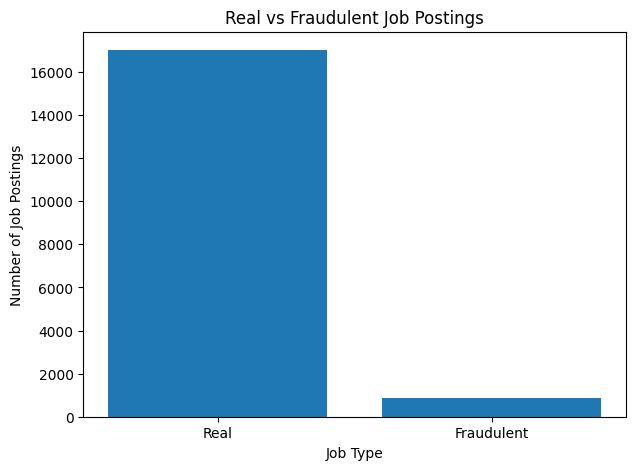

In [45]:
# ============================================================
# 7. PLOT REAL VS FRAUDULENT JOB POSTINGS
# ============================================================

real_jobs = (df["fraudulent"] == 0).sum()
fraudulent_jobs = (df["fraudulent"] == 1).sum()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Real", "Fraudulent"],
    [real_jobs, fraudulent_jobs]
)

plt.title("Real vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

plt.show()

In [46]:
# ============================================================
# 8. SELECT IMPORTANT TEXT COLUMNS
# ============================================================

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

print("\nText columns used for NLP:")
print(text_columns)


Text columns used for NLP:
['title', 'company_profile', 'description', 'requirements', 'benefits']


In [47]:
# ============================================================
# 9. HANDLE MISSING VALUES IN TEXT COLUMNS
# ============================================================

for column in text_columns:
    df[column] = df[column].fillna("")

In [48]:
# ============================================================
# 10. COMBINE TEXT COLUMNS
# ============================================================

df["job_text"] = df[text_columns].apply(
    lambda row: " ".join(row.values.astype(str)),
    axis=1
)

print("\nCombined text example:")
print(df["job_text"].iloc[0][:1000])


Combined text example:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community a

In [49]:
# ============================================================
# 11. REMOVE EMPTY TEXT RECORDS
# ============================================================

df["job_text"] = df["job_text"].str.strip()

df = df[df["job_text"] != ""]

print("\nDataset shape after removing empty text:")
print(df.shape)


Dataset shape after removing empty text:
(17880, 19)


In [50]:
# ============================================================
# 12. NLP PREPROCESSING
# ============================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back
    return " ".join(words)


print("\nPreprocessing text...")


Preprocessing text...


In [51]:
# ============================================================
# 13. APPLY NLP PREPROCESSING
# ============================================================

df["clean_text"] = df["job_text"].apply(preprocess_text)

print("\nOriginal text:")
print(df["job_text"].iloc[0][:500])

print("\nCleaned text:")
print(df["clean_text"].iloc[0][:500])


Original text:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor

Cleaned text:
marketing intern food weve created groundbreaking awardwinning cooking site support connect celebrate home cook give everything need one placewe top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curated information food cooking attract talented home cook contributor country also publish wellknown professional like mario batali gwyneth paltrow danny meyer partnership

In [52]:
# ============================================================
# 14. REMOVE EMPTY CLEANED TEXT
# ============================================================

df = df[df["clean_text"].str.strip() != ""]

print("\nDataset shape after NLP preprocessing:")
print(df.shape)


Dataset shape after NLP preprocessing:
(17880, 20)


In [53]:
# ============================================================
# 15. DEFINE FEATURES AND TARGET
# ============================================================

X = df["clean_text"]
y = df["fraudulent"]

print("\nFeatures:", X.shape)
print("Target:", y.shape)


Features: (17880,)
Target: (17880,)


In [56]:
# ============================================================
# 16. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


TRAIN / TEST SPLIT
Training samples: 14304
Testing samples: 3576


In [55]:
# ============================================================
# 17. TF-IDF FEATURE EXTRACTION
# ============================================================

print("\n" + "=" * 60)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 60)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


TF-IDF FEATURE EXTRACTION
Training TF-IDF shape: (14304, 10000)
Testing TF-IDF shape: (3576, 10000)


In [57]:
# ============================================================
# 18. LOGISTIC REGRESSION MODEL
# ============================================================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = logistic_model.predict(X_test_tfidf)


LOGISTIC REGRESSION


In [58]:
# ============================================================
# 19. LOGISTIC REGRESSION EVALUATION
# ============================================================

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("\nLogistic Regression Results")

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Real", "Fraudulent"],
        zero_division=0
    )
)


Logistic Regression Results
Accuracy : 0.9697986577181208
Precision: 0.6359832635983264
Recall   : 0.8786127167630058
F1 Score : 0.7378640776699029

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      3403
  Fraudulent       0.64      0.88      0.74       173

    accuracy                           0.97      3576
   macro avg       0.81      0.93      0.86      3576
weighted avg       0.98      0.97      0.97      3576



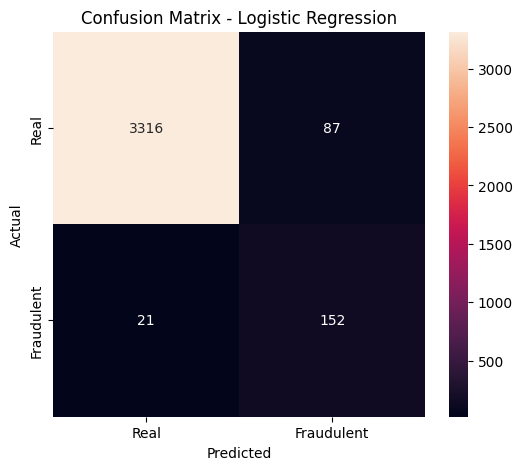

In [59]:
# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fraudulent"],
    yticklabels=["Real", "Fraudulent"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
# ============================================================
# 21. NAIVE BAYES MODEL
# ============================================================

print("\n" + "=" * 60)
print("NAIVE BAYES")
print("=" * 60)

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(X_test_tfidf)


NAIVE BAYES


In [61]:
# ============================================================
# 22. NAIVE BAYES EVALUATION
# ============================================================

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

print("\nNaive Bayes Results")

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Real", "Fraudulent"],
        zero_division=0
    )
)


Naive Bayes Results
Accuracy : 0.9636465324384788
Precision: 0.7471264367816092
Recall   : 0.37572254335260113
F1 Score : 0.5

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      3403
  Fraudulent       0.75      0.38      0.50       173

    accuracy                           0.96      3576
   macro avg       0.86      0.68      0.74      3576
weighted avg       0.96      0.96      0.96      3576



In [62]:
# ============================================================
# 23. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_nb
    ],

    "Precision": [
        precision_lr,
        precision_nb
    ],

    "Recall": [
        recall_lr,
        recall_nb
    ],

    "F1 Score": [
        f1_lr,
        f1_nb
    ]

})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(results)


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.969799,0.635983,0.878613,0.737864
1,Naive Bayes,0.963647,0.747126,0.375723,0.500000


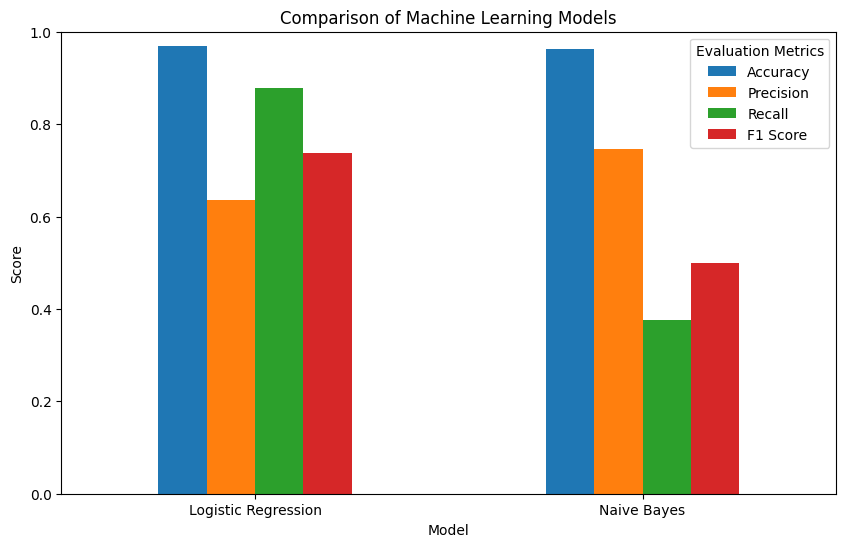

In [63]:
# ============================================================
# 24. MODEL COMPARISON GRAPH
# ============================================================

results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics"
)

plt.show()

In [64]:
# ============================================================
# 25. BEST MODEL
# ============================================================

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("\nBest model based on F1 Score:")
print(best_model_name)


Best model based on F1 Score:
Logistic Regression


In [65]:
# ============================================================
# 26. SAMPLE PREDICTION FUNCTION
# ============================================================

def predict_job(job_description):

    # Preprocess input
    cleaned = preprocess_text(job_description)

    # Convert to TF-IDF
    vector = tfidf.transform([cleaned])

    # Prediction
    prediction = logistic_model.predict(vector)[0]

    # Probability
    probability = logistic_model.predict_proba(vector)[0]

    if prediction == 1:
        result = "Fraudulent Job Posting"
    else:
        result = "Real Job Posting"

    print("\nPrediction:", result)

    print(
        "Probability of Real:",
        round(probability[0] * 100, 2),
        "%"
    )

    print(
        "Probability of Fraudulent:",
        round(probability[1] * 100, 2),
        "%"
    )

In [70]:
# ============================================================
# 27. TEST WITH A SAMPLE JOB
# ============================================================

sample_job = """
We are looking for a highly motivated software developer.
The candidate should have good programming skills and
experience with Python and web development.
The selected candidate will work with our development team
and receive a competitive salary and benefits.
"""

predict_job(sample_job)


Prediction: Real Job Posting
Probability of Real: 83.4 %
Probability of Fraudulent: 16.6 %


In [71]:
# ============================================================
# 28. SAVE TF-IDF VECTORIZER AND MODEL
# ============================================================

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    logistic_model,
    "fake_job_detection_model.pkl"
)

print("\n" + "=" * 60)
print("FILES SAVED SUCCESSFULLY")
print("=" * 60)

print("tfidf_vectorizer.pkl")
print("fake_job_detection_model.pkl")


FILES SAVED SUCCESSFULLY
tfidf_vectorizer.pkl
fake_job_detection_model.pkl


In [69]:
# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("Dataset size:", df.shape)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nLogistic Regression:")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))

print("\nNaive Bayes:")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

print("\nBest Model:", best_model_name)


PROJECT COMPLETED
Dataset size: (17880, 20)
Training samples: 14304
Testing samples: 3576

Logistic Regression:
Accuracy : 0.9698
Precision: 0.636
Recall   : 0.8786
F1 Score : 0.7379

Naive Bayes:
Accuracy : 0.9636
Precision: 0.7471
Recall   : 0.3757
F1 Score : 0.5

Best Model: Logistic Regression
